<a href="https://colab.research.google.com/github/Konstantinosil/Chortareas-Linardatos-Central-Bank-Credibility-Under-the-Shadow-Rate-Stance/blob/main/Central_Bank_Credibility_Under_the_Shadow_Rate_Stance_both_sr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


WU & XIA PIPELINE (FULL)

=== Data coverage (non-missing counts) ===
SR {'EU': np.int64(169), 'UK': np.int64(169), 'US': np.int64(169)}
INF {'EU': np.int64(169), 'UK': np.int64(169), 'US': np.int64(169)}
GDP {'EU': np.int64(157), 'UK': np.int64(169), 'US': np.int64(157)}


=== Stationarity diagnostics (ADF) ===
(ADF sample restricted to date >= 2010-01-01)
econ   series   adf_stat      p_value  used_lags  nobs
  US SR_level  -1.882715 3.402357e-01         12   132
  US      dSR  -3.047242 3.071199e-02          9   135
  EU SR_level  -1.083765 7.215027e-01          0   144
  EU      dSR -12.292040 7.787655e-23          0   144
  UK SR_level  -4.220298 6.086671e-04          7   137
  UK      dSR  -0.659235 8.570280e-01          5   139

=== EGARCH meta (baseline SR-level) ===
   ar_lags egarch_ok
US       0      True
EU       0      True
UK       0      True

=== Anchor stats (pooled scaling) ===
{'q_lo': -1.9768540176810874, 'q_hi': 1.0508624963717477, 'anchor_end': '2010-12-01'}


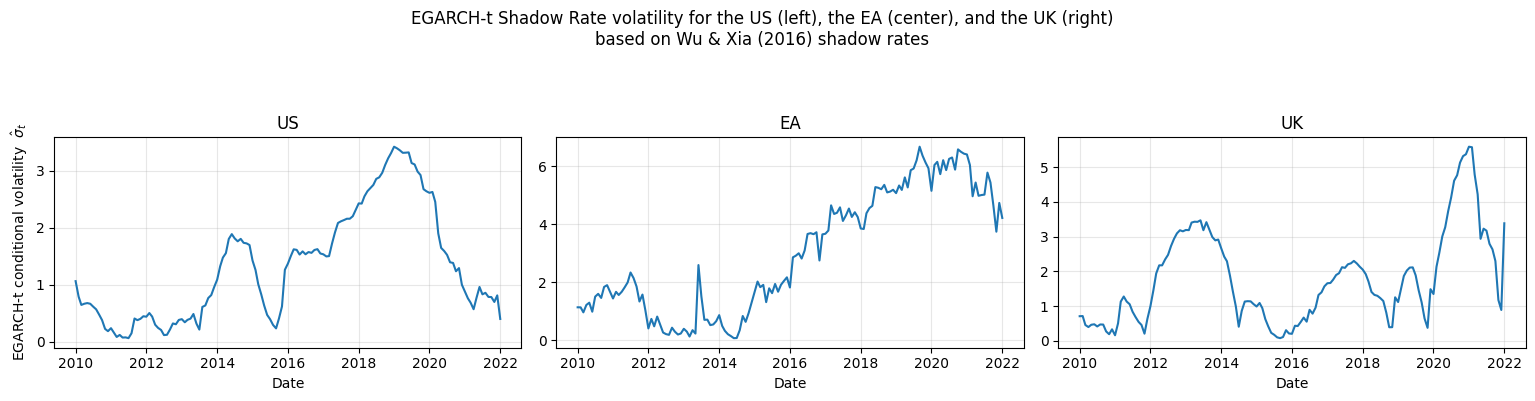

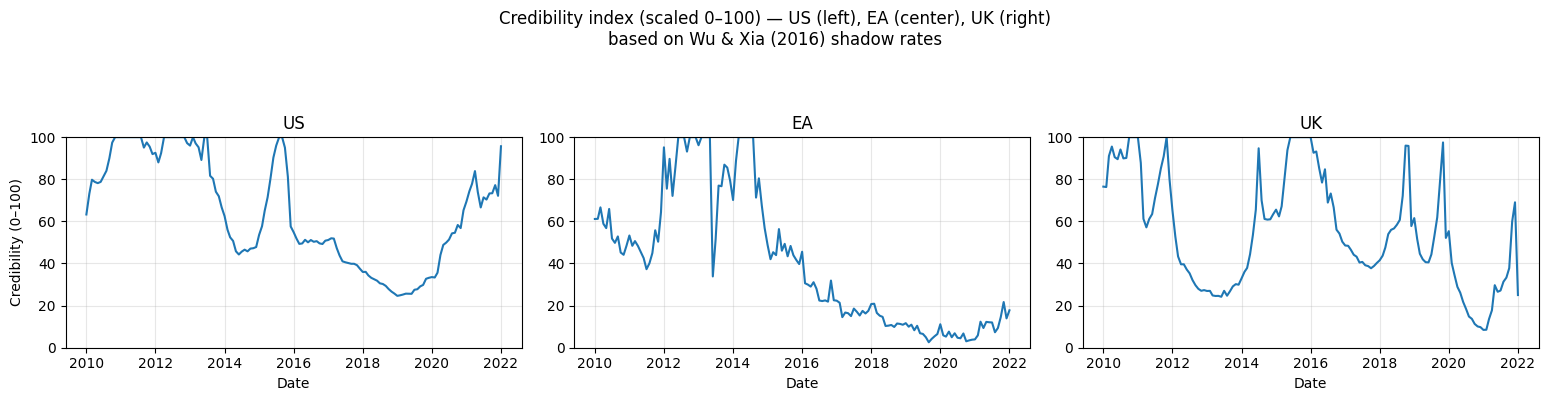


=== Stationarity diagnostics (ADF) — credibility ===
(ADF sample restricted to date >= 2010-01-01)
econ            series  adf_stat  p_value  used_lags  nobs
  US cred_scaled_0_100 -1.486227 0.540313          2   142
  EU cred_scaled_0_100 -1.373534 0.594896          1   143
  UK cred_scaled_0_100 -2.143596 0.227350          0   144

=== Robustness: baseline EGARCH credibility vs GJR-GARCH credibility ===
econ  corr(egarch,gjr)  T_common
  US          0.989707       169
  EU          0.973072       169
  UK          0.991215       169
Pooled corr(egarch,gjr) = 0.984 (N=507)

=== GJR meta ===
   ar_lags gjr_ok
US       0   True
EU       0   True
UK       0   True

==================== SACRIFICE RATIO REGRESSIONS ====================
(Estimation sample restricted to date >= 2010-01-01)
Model: SR_H12 ~ const + cred(t-6) + country dummies (pooled)
Notes: SR uses overlapping windows; HAC(maxlags=H) is conservative under persistence.

[Baseline cred = EGARCH]  HC3:  b=-0.0230, se=0.0061, p=

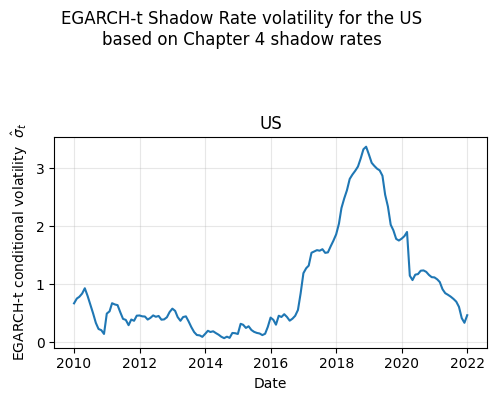

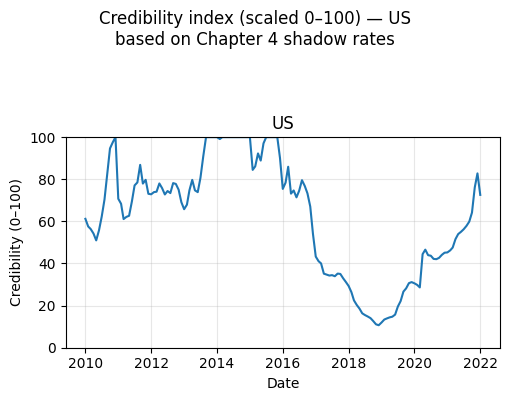


==================== SACRIFICE RATIO REGRESSIONS (Chapter 4 SR) ====================
(Estimation sample restricted to date >= 2010-01-01)
Model: SR_H12 ~ const + cred(t-6) + country dummies (pooled)
Notes: SR uses overlapping windows; HAC(maxlags=H) is conservative under persistence.

HC3:  b=-0.0155, se=0.0056, p=0.0055 | N=188
HAC:  b=-0.0155, se=0.0116, p=0.1808 | maxlags=12

--- Regression table (HC3) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3508      0.174      7.768      0.000       1.010       1.692
cred_lag6     -0.0155      0.006     -2.778      0.005      -0.026      -0.005
ent_UK         1.1655      0.595      1.958      0.050      -0.001       2.332
ent_US         0.3727      0.474      0.787      0.432      -0.556       1.302

--- Regression table (HAC) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
-

In [10]:
%pip -q install arch statsmodels openpyxl

import warnings, logging, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="No frequency information was provided, so inferred frequency")
warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
np.random.seed(42)

def resolve_file(p: pathlib.Path) -> pathlib.Path:
    """Works both in Colab (/content) and in this environment (/mnt/data)."""
    p = pathlib.Path(p)
    if p.exists():
        return p
    alt = pathlib.Path("/mnt/data") / p.name
    if alt.exists():
        return alt
    raise FileNotFoundError(f"Missing file: {p} (also tried {alt})")

def parse_sheet(name: str):
    key = {
        'shadow rates':'SR',
        'policy rates':'POLICY',
        'inflation':'INF',
        'volatility':'VOL',
        'composite leader indicator':'CLI'
    }
    parts = name.split()
    econ = parts[-1].upper()
    head = ' '.join(parts[:-1]).lower()
    for k, v in key.items():
        if k in head:
            return v, econ
    if head.startswith('rgdp'):
        return 'GDP', econ
    return None, None

def to_monthly(s: pd.Series) -> pd.Series:
    s = pd.Series(s).copy()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index)
    if s.index.has_duplicates:
        s = s.groupby(level=0).mean()

    f = (pd.infer_freq(s.index[:5]) or '').upper()
    if f.startswith(('D','B')):
        s = s.resample('MS').last()
    elif f.startswith('Q'):
        s = s.resample('QS').last().interpolate('linear').resample('MS').ffill()
    else:
        if not s.index.is_month_start.all():
            s.index = s.index.to_period('M').to_timestamp('start')
        s = s.asfreq('MS')
    return s

def ensure_ms(s: pd.Series) -> pd.Series:
    s = pd.Series(s).copy()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index)
    if not s.index.is_month_start.all():
        s.index = s.index.to_period('M').to_timestamp('start')
    if s.index.has_duplicates:
        s = s.groupby(level=0).mean()
    return s.asfreq('MS')

def load_panel(path: pathlib.Path, econ_list, start, end) -> pd.DataFrame:
    xls = pd.read_excel(path, sheet_name=None)
    raw = {}
    for sheet, df in xls.items():
        var, econ = parse_sheet(sheet)
        if var and econ in econ_list:
            df = df.iloc[:, :2].copy()
            df.columns = ['date', var]
            df['date'] = pd.to_datetime(df['date'])
            s = to_monthly(df.set_index('date')[var])
            raw[(econ, var)] = s.loc[str(start):str(end)]
    if not raw:
        raise ValueError("No matching sheets found. Check sheet names / ECON list.")
    panel = (pd.concat(raw, axis=1)
             .swaplevel(0,1, axis=1).sort_index(axis=1)
             .stack(level=1).rename_axis(['date','econ']).sort_index())
    if panel.index.duplicated().any():
        panel = panel.groupby(level=['date','econ']).mean()
    return panel

def adf_row(series: pd.Series, name: str, econ: str):
    x = pd.Series(series).dropna()
    if len(x) < 20:
        return [econ, name, np.nan, np.nan, np.nan, len(x)]
    stat, pval, lags, nobs, *_ = adfuller(x.values, autolag='AIC')
    return [econ, name, float(stat), float(pval), int(lags), int(nobs)]

def inflation_yoy_from_cpi(cpi: pd.Series) -> pd.Series:
    cpi = ensure_ms(pd.Series(cpi).astype(float)).dropna()
    l = np.log(cpi.replace([np.inf,-np.inf], np.nan)).dropna()
    return 100.0 * (l - l.shift(12))

def select_ar(y: pd.Series, max_p=2):
    y = ensure_ms(pd.Series(y).dropna())
    best, lag = np.inf, 0
    for p in range(max_p+1):
        try:
            aic = smt.ARIMA(y, order=(p,0,0)).fit(method='innovations_mle', disp=0).aic
            if aic < best:
                best, lag = aic, p
        except:
            pass
    return lag

def _fallback_vol(y: pd.Series, roll: int):
    y = ensure_ms(pd.Series(y).astype(float))
    return y.rolling(roll).std(ddof=0)

def fit_egarch_t_level(y: pd.Series, lags_ar: int, min_T: int, fallback_roll: int):
    y = ensure_ms(pd.Series(y).astype(float).dropna())
    if len(y) < min_T:
        return None, _fallback_vol(y, fallback_roll)
    mu, sd = y.mean(), y.std(ddof=0)
    if (not np.isfinite(sd)) or sd == 0:
        return None, _fallback_vol(y, fallback_roll)

    y_std = (y - mu)/sd
    try:
        am = arch_model(
            y_std, mean='AR', lags=lags_ar,
            vol='EGARCH', p=1, o=0, q=1,
            dist='t', rescale=True
        )
        res = am.fit(disp='off', show_warning=False, options={'maxiter': 2500})
        sig = pd.Series(res.conditional_volatility, index=y.index).replace([np.inf,-np.inf], np.nan)
        if sig.isna().mean() > 0.20:
            return None, _fallback_vol(y, fallback_roll)
        return res, sig*sd
    except Exception as e:
        logging.warning(f"EGARCH failed: {e}; fallback rolling std.")
        return None, _fallback_vol(y, fallback_roll)

def fit_gjr_garch_t_level(y: pd.Series, lags_ar: int, min_T: int, fallback_roll: int):
    y = ensure_ms(pd.Series(y).astype(float).dropna())
    if len(y) < min_T:
        return None, _fallback_vol(y, fallback_roll)
    mu, sd = y.mean(), y.std(ddof=0)
    if (not np.isfinite(sd)) or sd == 0:
        return None, _fallback_vol(y, fallback_roll)

    y_std = (y - mu)/sd
    try:
        am = arch_model(
            y_std, mean='AR', lags=lags_ar,
            vol='GARCH', p=1, o=1, q=1,
            dist='t', rescale=True
        )
        res = am.fit(disp='off', show_warning=False, options={'maxiter': 2500})
        sig = pd.Series(res.conditional_volatility, index=y.index).replace([np.inf,-np.inf], np.nan)
        if sig.isna().mean() > 0.20:
            return None, _fallback_vol(y, fallback_roll)
        return res, sig*sd
    except Exception as e:
        logging.warning(f"GJR-GARCH failed: {e}; fallback rolling std.")
        return None, _fallback_vol(y, fallback_roll)

def scale_to_0_100(rawcred: pd.DataFrame, anchor_end: str, p_lo=5, p_hi=95):
    anchor_end = pd.Timestamp(anchor_end)
    base = rawcred.loc[rawcred.index <= anchor_end].stack().dropna()
    if base.empty:
        raise ValueError("Anchor window empty. Check ANCHOR_END.")
    q_lo = np.nanpercentile(base.values, p_lo)
    q_hi = np.nanpercentile(base.values, p_hi)
    width = max(1e-8, q_hi - q_lo)
    scaled = (rawcred - q_lo) / width * 100.0
    stats = dict(q_lo=float(q_lo), q_hi=float(q_hi), anchor_end=str(anchor_end.date()))
    return scaled.clip(0, 100), stats

def hp_gap_from_gdp(gdp: pd.Series, lam: float) -> pd.Series:
    s = ensure_ms(pd.Series(gdp).astype(float)).dropna()
    lvl = s.replace([np.inf,-np.inf], np.nan).dropna().clip(lower=1e-8)
    loglvl = np.log(lvl).interpolate('time')
    cycle, _ = sm.tsa.filters.hpfilter(loglvl, lamb=lam)
    return (cycle*100.0).rename('gap')

def winsorize(s: pd.Series, p=(0.01,0.99)) -> pd.Series:
    s = pd.Series(s).copy()
    if s.dropna().empty:
        return s
    lo, hi = s.quantile(p[0]), s.quantile(p[1])
    return s.clip(lo, hi)

def sacrifice_ratio(pi: pd.Series, gap: pd.Series, H: int, min_abs_dpi: float, winsor_pcts):
    pi  = ensure_ms(pi).astype(float).sort_index()
    gap = ensure_ms(gap).astype(float).sort_index()
    cost_pm = gap.clip(upper=0).abs().rolling(H, min_periods=H).sum()
    cost_py = cost_pm / 12.0
    dpi = pi - pi.shift(H)
    sr = (cost_py / dpi.abs()).where(dpi < -min_abs_dpi)
    return winsorize(sr, winsor_pcts).rename("SR")

def run_sr_reg(sr_panel_long: pd.DataFrame, cred_col: str, H: int, L: int, analysis_start=None):
    df = sr_panel_long.copy().sort_values(['econ','date'])
    df[f'cred_lag{L}'] = df.groupby('econ')[cred_col].shift(L)

    if analysis_start is not None:
        analysis_start = pd.Timestamp(analysis_start)
        df = df[df['date'] >= analysis_start].copy()

    use = df[['SR', f'cred_lag{L}', 'econ']].dropna().copy()
    D = pd.get_dummies(use['econ'], prefix='ent', drop_first=True, dtype=int)
    X = pd.concat([use[[f'cred_lag{L}']], D], axis=1)
    X = sm.add_constant(X, has_constant='add')
    y = use['SR']

    res_hc3 = sm.OLS(y, X).fit(cov_type='HC3')
    res_hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': H})
    return res_hc3, res_hac, int(res_hc3.nobs)

def coef_line(res, var):
    b = float(res.params.get(var, np.nan))
    se = float(res.bse.get(var, np.nan))
    p  = float(res.pvalues.get(var, np.nan))
    return b, se, p

def prep_panel(cfg):
    cfg = cfg.copy()
    cfg['FILE'] = resolve_file(cfg['FILE'])

    panel = load_panel(cfg['FILE'], cfg['ECON'], cfg['START'], cfg['END'])

    needed = {'SR','INF','GDP'}
    missing = needed - set(panel.columns)
    if missing:
        raise KeyError(f"Missing variables: {missing}")

    print("=== Data coverage (non-missing counts) ===")
    for v in ['SR','INF','GDP']:
        cnt = panel[v].groupby('econ').apply(lambda s: int(s.notna().sum()))
        print(v, dict(cnt))

    inf_wide = panel['INF'].unstack('econ').sort_index()
    inf_wide = inf_wide.loc[~inf_wide.index.duplicated(keep='last')]
    pi_wide = inf_wide.apply(inflation_yoy_from_cpi, axis=0) if cfg['INF_IS_CPI_INDEX'] else inf_wide
    pi_long = pi_wide.stack().rename('PI').groupby(level=['date','econ']).mean()

    panel = (panel.reset_index()
             .merge(pi_long.to_frame('PI').reset_index(), on=['date','econ'], how='left')
             .set_index(['date','econ']).sort_index())
    if panel.index.duplicated().any():
        panel = panel.groupby(level=['date','econ']).mean()
    return panel, cfg

def plot_vol_and_cred(sigma_df, cred_df, caption_tag, analysis_start=None, econ_subset=None):
    """
    econ_subset: list like ['US','EU','UK'] or ['US'].
    """
    label_map = {'US':'US','EU':'EA','UK':'UK'}
    if econ_subset is None:
        econ_subset = ['US','EU','UK']

    if analysis_start is not None:
        analysis_start = pd.Timestamp(analysis_start)
        sigma_df = sigma_df.loc[sigma_df.index >= analysis_start]
        cred_df  = cred_df.loc[cred_df.index >= analysis_start]

    econ_subset = [e.upper() for e in econ_subset]

    n = len(econ_subset)
    fig, axs = plt.subplots(1, n, figsize=(5.2*n, 3.6), sharex=True)
    if n == 1:
        axs = [axs]

    for ax, econ in zip(axs, econ_subset):
        s = sigma_df[econ].dropna()
        ax.plot(s.index, s.values)
        ax.set_title(label_map.get(econ, econ))
        ax.set_xlabel("Date")
        ax.grid(alpha=0.3)

    axs[0].set_ylabel(r"EGARCH-t conditional volatility  $\hat{\sigma}_t$")
    if n == 1:
        fig.suptitle(
            f"EGARCH-t Shadow Rate volatility for the {label_map.get(econ_subset[0], econ_subset[0])}\n"
            f"based on {caption_tag}",
            y=1.10
        )
    else:
        fig.suptitle(
            "EGARCH-t Shadow Rate volatility for the US (left), the EA (center), and the UK (right)\n"
            f"based on {caption_tag}",
            y=1.10
        )
    fig.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1, n, figsize=(5.2*n, 3.6), sharex=True)
    if n == 1:
        axs = [axs]

    for ax, econ in zip(axs, econ_subset):
        s = cred_df[econ].dropna()
        ax.plot(s.index, s.values)
        ax.set_title(label_map.get(econ, econ))
        ax.set_xlabel("Date")
        ax.set_ylim(0, 100)
        ax.grid(alpha=0.3)

    axs[0].set_ylabel("Credibility (0–100)")
    if n == 1:
        fig.suptitle(
            f"Credibility index (scaled 0–100) — {label_map.get(econ_subset[0], econ_subset[0])}\n"
            f"based on {caption_tag}",
            y=1.10
        )
    else:
        fig.suptitle(
            "Credibility index (scaled 0–100) — US (left), EA (center), UK (right)\n"
            f"based on {caption_tag}",
            y=1.10
        )
    fig.tight_layout()
    plt.show()

def run_full_wuxia(cfg, caption_tag="Wu & Xia (2016) shadow rates"):
    print("\n" + "="*90)
    print("WU & XIA PIPELINE (FULL)")
    print("="*90 + "\n")

    analysis_start = cfg.get('ANALYSIS_START', None)

    panel, cfg = prep_panel(cfg)

    print("\n" + "="*70)
    print("="*70 + "\n")

    if cfg['RUN_ADF']:
        adf_rows = []
        for e in cfg['ECON']:
            sr_full = ensure_ms(panel.xs(e, level='econ')['SR'])
            sr_lvl  = sr_full
            dsr     = sr_full.diff()
            if analysis_start is not None:
                t0 = pd.Timestamp(analysis_start)
                sr_lvl = sr_lvl.loc[sr_lvl.index >= t0]
                dsr    = dsr.loc[dsr.index >= t0]
            adf_rows.append(adf_row(sr_lvl, 'SR_level', e))
            adf_rows.append(adf_row(dsr, 'dSR', e))
        adf_tab = pd.DataFrame(adf_rows, columns=['econ','series','adf_stat','p_value','used_lags','nobs'])
        print("=== Stationarity diagnostics (ADF) ===")
        if analysis_start is not None:
            print(f"(ADF sample restricted to date >= {pd.Timestamp(analysis_start).date()})")
        print(adf_tab.to_string(index=False))

    ar_lags = {e: None for e in cfg['ECON']}
    sigma_eg, eg_meta = {}, {}
    for e in cfg['ECON']:
        sr = ensure_ms(panel.xs(e, level='econ')['SR']).dropna()
        p = select_ar(sr, cfg['AR_MAX'])
        ar_lags[e] = int(p)
        res, sig = fit_egarch_t_level(sr, lags_ar=p, min_T=cfg['MIN_T'], fallback_roll=cfg['FALLBACK_ROLL'])
        sigma_eg[e] = sig
        eg_meta[e] = dict(ar_lags=int(p), egarch_ok=bool(res is not None))
    sigma_eg = pd.DataFrame(sigma_eg).sort_index()

    print("\n=== EGARCH meta (baseline SR-level) ===")
    print(pd.DataFrame(eg_meta).T)

    cred_eg_raw = (-np.log(sigma_eg.clip(lower=1e-10))).rename_axis('date')
    cred_eg_sc, anchor_stats = scale_to_0_100(cred_eg_raw, cfg['ANCHOR_END'], cfg['P_LO'], cfg['P_HI'])

    print("\n=== Anchor stats (pooled scaling) ===")
    print(anchor_stats)

    if cfg['PLOTS']:
        plot_vol_and_cred(
            sigma_eg, cred_eg_sc, caption_tag,
            analysis_start=analysis_start, econ_subset=['US','EU','UK']
        )

    if cfg['RUN_ADF']:
        adf_rows_c = []
        for e in cfg['ECON']:
            c = cred_eg_sc[e]
            if analysis_start is not None:
                c = c.loc[c.index >= pd.Timestamp(analysis_start)]
            adf_rows_c.append(adf_row(c, 'cred_scaled_0_100', e))
        adf_cred = pd.DataFrame(adf_rows_c, columns=['econ','series','adf_stat','p_value','used_lags','nobs'])
        print("\n=== Stationarity diagnostics (ADF) — credibility ===")
        if analysis_start is not None:
            print(f"(ADF sample restricted to date >= {pd.Timestamp(analysis_start).date()})")
        print(adf_cred.to_string(index=False))

    sigma_gjr, gjr_meta = {}, {}
    for e in cfg['ECON']:
        sr = ensure_ms(panel.xs(e, level='econ')['SR']).dropna()
        p = ar_lags[e] if ar_lags[e] is not None else select_ar(sr, cfg['AR_MAX'])
        res, sig = fit_gjr_garch_t_level(sr, lags_ar=p, min_T=cfg['MIN_T'], fallback_roll=cfg['FALLBACK_ROLL'])
        sigma_gjr[e] = sig
        gjr_meta[e] = dict(ar_lags=int(p), gjr_ok=bool(res is not None))
    sigma_gjr = pd.DataFrame(sigma_gjr).sort_index()

    cred_gjr_raw = (-np.log(sigma_gjr.clip(lower=1e-10))).rename_axis('date')
    cred_gjr_sc, _ = scale_to_0_100(cred_gjr_raw, cfg['ANCHOR_END'], cfg['P_LO'], cfg['P_HI'])

    rows = []
    for e in cfg['ECON']:
        tmp = pd.concat([cred_eg_sc[e].rename('egarch'), cred_gjr_sc[e].rename('gjr')], axis=1).dropna()
        rows.append([e, float(tmp['egarch'].corr(tmp['gjr'])) if len(tmp) > 5 else np.nan, int(len(tmp))])
    pooled = pd.concat([cred_eg_sc.stack().rename('egarch'), cred_gjr_sc.stack().rename('gjr')], axis=1).dropna()

    print("\n=== Robustness: baseline EGARCH credibility vs GJR-GARCH credibility ===")
    print(pd.DataFrame(rows, columns=['econ','corr(egarch,gjr)','T_common']).to_string(index=False))
    print(f"Pooled corr(egarch,gjr) = {float(pooled['egarch'].corr(pooled['gjr'])):.3f} (N={len(pooled)})")
    print("\n=== GJR meta ===")
    print(pd.DataFrame(gjr_meta).T)

    sr_rows = []
    for e in cfg['ECON']:
        sub = panel.xs(e, level='econ').sort_index()
        gap = hp_gap_from_gdp(sub['GDP'], lam=cfg['HP_LAMBDA_M'])
        pi  = sub['PI']
        srH = sacrifice_ratio(pi, gap, H=cfg['SR_H'], min_abs_dpi=cfg['MIN_ABS_DPI'], winsor_pcts=cfg['WINSOR_PCTS'])
        sr_rows.append(pd.DataFrame({'date': srH.index, 'econ': e, 'SR': srH.values}))
    sr_df = pd.concat(sr_rows, axis=0).dropna(subset=['SR']).sort_values(['econ','date']).reset_index(drop=True)

    cred_eg_long = cred_eg_sc.stack().rename('cred_eg'); cred_eg_long.index.names = ['date','econ']
    cred_gjr_long = cred_gjr_sc.stack().rename('cred_gjr'); cred_gjr_long.index.names = ['date','econ']
    cred_long = (pd.concat([cred_eg_long, cred_gjr_long], axis=1)
                 .reset_index()
                 .groupby(['date','econ'], as_index=False).mean())

    sr_df = (sr_df.merge(cred_long, on=['date','econ'], how='left')
             .dropna(subset=['cred_eg','cred_gjr'])
             .sort_values(['econ','date'])
             .reset_index(drop=True))

    L = cfg['SR_LAG']
    xname = f'cred_lag{L}'

    res_hc3_eg, res_hac_eg, N_eg = run_sr_reg(sr_df, cred_col='cred_eg', H=cfg['SR_H'], L=L, analysis_start=analysis_start)
    res_hc3_gjr, res_hac_gjr, N_gjr = run_sr_reg(sr_df, cred_col='cred_gjr', H=cfg['SR_H'], L=L, analysis_start=analysis_start)

    print("\n==================== SACRIFICE RATIO REGRESSIONS ====================")
    if analysis_start is not None:
        print(f"(Estimation sample restricted to date >= {pd.Timestamp(analysis_start).date()})")
    print(f"Model: SR_H12 ~ const + cred(t-{L}) + country dummies (pooled)")
    print(f"Notes: SR uses overlapping windows; HAC(maxlags=H) is conservative under persistence.\n")

    b,se,p = coef_line(res_hc3_eg, xname)
    print(f"[Baseline cred = EGARCH]  HC3:  b={b:.4f}, se={se:.4f}, p={p:.4f} | N={N_eg}")
    b,se,p = coef_line(res_hac_eg, xname)
    print(f"[Baseline cred = EGARCH]  HAC:  b={b:.4f}, se={se:.4f}, p={p:.4f} | maxlags=12")

    b,se,p = coef_line(res_hc3_gjr, xname)
    print(f"\n[Robust cred = GJR]       HC3:  b={b:.4f}, se={se:.4f}, p={p:.4f} | N={N_gjr}")
    b,se,p = coef_line(res_hac_gjr, xname)
    print(f"[Robust cred = GJR]       HAC:  b={b:.4f}, se={se:.4f}, p={p:.4f} | maxlags=12")

    print("\n--- EGARCH credibility regression table (HC3) ---")
    print(res_hc3_eg.summary().tables[1])
    print("\n--- EGARCH credibility regression table (HAC) ---")
    print(res_hac_eg.summary().tables[1])

    print("\n--- GJR credibility regression table (HC3) ---")
    print(res_hc3_gjr.summary().tables[1])
    print("\n--- GJR credibility regression table (HAC) ---")
    print(res_hac_gjr.summary().tables[1])

def run_light_chapter4(cfg, caption_tag="Chapter 4 shadow rates"):
    print("\n" + "="*90)
    print("CHAPTER 4 SHADOW RATE PIPELINE (LIGHT: metric+scaling+plots(US-only)+SR+reg only)")
    print("="*90 + "\n")

    analysis_start = cfg.get('ANALYSIS_START', None)

    panel, cfg = prep_panel(cfg)

    sigma_eg, eg_meta = {}, {}
    for e in cfg['ECON']:
        sr = ensure_ms(panel.xs(e, level='econ')['SR']).dropna()
        p = select_ar(sr, cfg['AR_MAX'])
        res, sig = fit_egarch_t_level(sr, lags_ar=p, min_T=cfg['MIN_T'], fallback_roll=cfg['FALLBACK_ROLL'])
        sigma_eg[e] = sig
        eg_meta[e] = dict(ar_lags=int(p), egarch_ok=bool(res is not None))
    sigma_eg = pd.DataFrame(sigma_eg).sort_index()

    cred_raw = (-np.log(sigma_eg.clip(lower=1e-10))).rename_axis('date')
    cred_sc, anchor_stats = scale_to_0_100(cred_raw, cfg['ANCHOR_END'], cfg['P_LO'], cfg['P_HI'])

    print("\n=== EGARCH meta (US only) ===")
    print(pd.DataFrame(eg_meta).T.loc[['US']])
    print("\n=== Anchor stats (pooled scaling) ===")
    print(anchor_stats)

    if cfg['PLOTS']:
        plot_vol_and_cred(
            sigma_eg, cred_sc, caption_tag,
            analysis_start=analysis_start, econ_subset=['US']
        )

    sr_rows = []
    for e in cfg['ECON']:
        sub = panel.xs(e, level='econ').sort_index()
        gap = hp_gap_from_gdp(sub['GDP'], lam=cfg['HP_LAMBDA_M'])
        pi  = sub['PI']
        srH = sacrifice_ratio(pi, gap, H=cfg['SR_H'], min_abs_dpi=cfg['MIN_ABS_DPI'], winsor_pcts=cfg['WINSOR_PCTS'])
        sr_rows.append(pd.DataFrame({'date': srH.index, 'econ': e, 'SR': srH.values}))

    sr_df = (pd.concat(sr_rows, axis=0)
             .dropna(subset=['SR'])
             .sort_values(['econ','date'])
             .reset_index(drop=True))

    cred_long = (cred_sc.stack().rename('cred')
                 .reset_index()
                 .rename(columns={'level_0':'date', 'level_1':'econ'}))

    sr_df = (sr_df.merge(cred_long, on=['date','econ'], how='left')
             .dropna(subset=['cred'])
             .sort_values(['econ','date'])
             .reset_index(drop=True))

    L = cfg['SR_LAG']
    xname = f'cred_lag{L}'
    res_hc3, res_hac, N = run_sr_reg(sr_df, cred_col='cred', H=cfg['SR_H'], L=L, analysis_start=analysis_start)

    print("\n==================== SACRIFICE RATIO REGRESSIONS (Chapter 4 SR) ====================")
    if analysis_start is not None:
        print(f"(Estimation sample restricted to date >= {pd.Timestamp(analysis_start).date()})")
    print(f"Model: SR_H12 ~ const + cred(t-{L}) + country dummies (pooled)")
    print(f"Notes: SR uses overlapping windows; HAC(maxlags=H) is conservative under persistence.\n")

    b,se,p = coef_line(res_hc3, xname)
    print(f"HC3:  b={b:.4f}, se={se:.4f}, p={p:.4f} | N={N}")
    b,se,p = coef_line(res_hac, xname)
    print(f"HAC:  b={b:.4f}, se={se:.4f}, p={p:.4f} | maxlags=12")

    print("\n--- Regression table (HC3) ---")
    print(res_hc3.summary().tables[1])
    print("\n--- Regression table (HAC) ---")
    print(res_hac.summary().tables[1])

CFG_WX = dict(
    FILE   = pathlib.Path('/content/chapter 4 august 2025 1st block.xlsx'),
    ECON   = ['US','EU','UK'],
    START  = '2008-01-01',
    END    = '2022-01-01',

    INF_IS_CPI_INDEX = True,

    AR_MAX = 2,
    MIN_T = 24,
    FALLBACK_ROLL = 12,

    ANCHOR_END = '2010-12-01',
    P_LO = 5,
    P_HI = 95,

    HP_LAMBDA_M = 129_600,
    SR_H = 12,
    SR_LAG = 6,
    MIN_ABS_DPI = 0.10,
    WINSOR_PCTS = (0.01, 0.99),

    RUN_ADF = True,
    PLOTS = True,

    ANALYSIS_START = '2010-01-01',
)

CFG_CH4 = dict(
    FILE   = pathlib.Path('/content/Central Bank Credibility Under the Shadow Rate Stance.xlsx'),
    ECON   = ['US','EU','UK'],
    START  = '2008-01-01',
    END    = '2022-01-01',

    INF_IS_CPI_INDEX = True,

    AR_MAX = 2,
    MIN_T = 24,
    FALLBACK_ROLL = 12,

    ANCHOR_END = '2010-12-01',
    P_LO = 5,
    P_HI = 95,

    HP_LAMBDA_M = 129_600,
    SR_H = 12,
    SR_LAG = 6,
    MIN_ABS_DPI = 0.10,
    WINSOR_PCTS = (0.01, 0.99),

    RUN_ADF = False,
    PLOTS = True,

    ANALYSIS_START = '2010-01-01',
)

run_full_wuxia(CFG_WX, caption_tag="Wu & Xia (2016) shadow rates")
run_light_chapter4(CFG_CH4, caption_tag="Chapter 4 shadow rates")